In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the data
df = pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


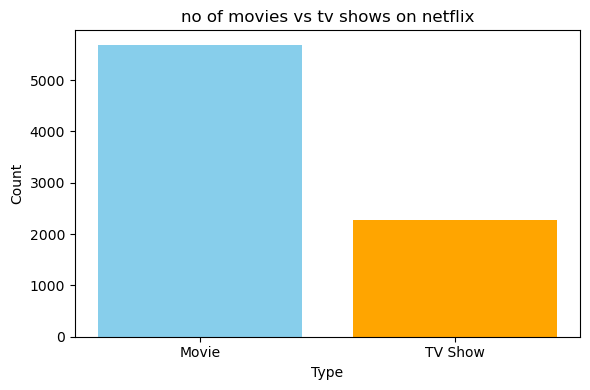

In [3]:
# clean the data
# bar chart
df = df.dropna(subset=['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color = ['skyblue', 'orange'])
plt.title('no of movies vs tv shows on netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movie and tv shows.png')
plt.show()

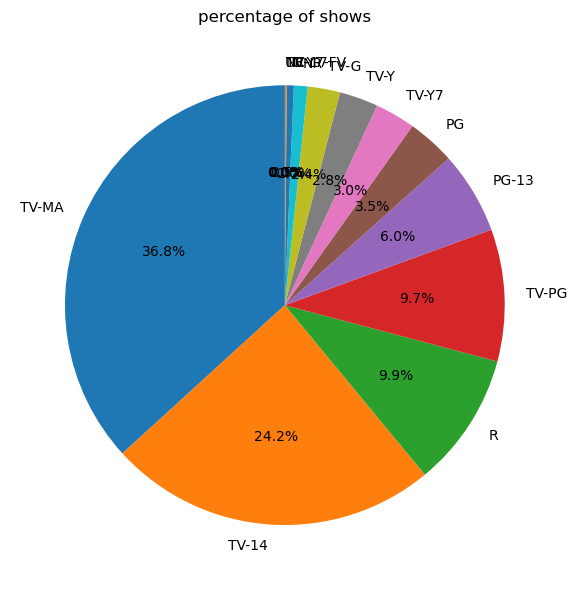

In [4]:
# pie chart
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('percentage of shows')
plt.tight_layout()
plt.savefig('shows_pie_chart.png')
plt.show()

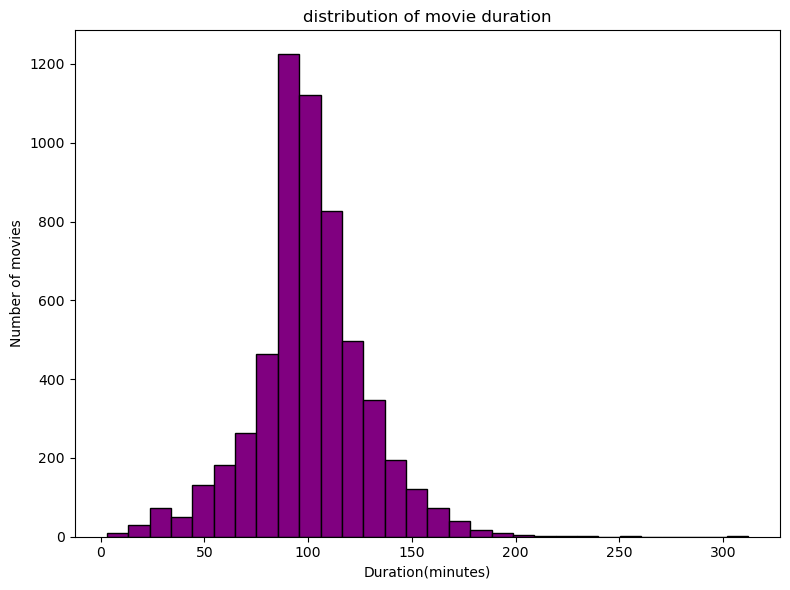

In [5]:
# histogram

movie_df = df[df['type']=='Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min','').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color = 'purple', edgecolor='black')
plt.title('distribution of movie duration')
plt.xlabel('Duration(minutes)')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show() 

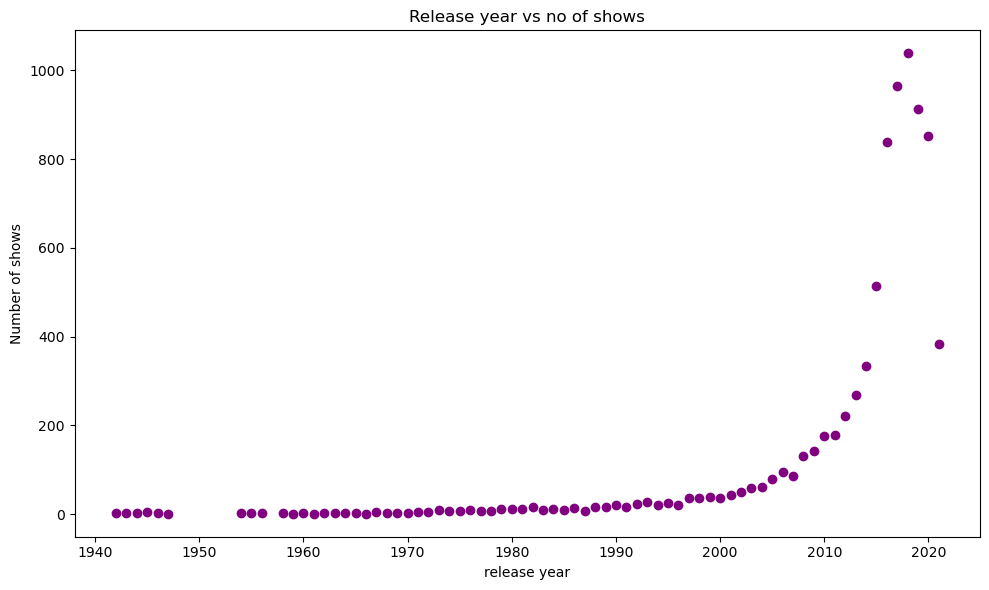

In [6]:
# scatter

release_counts = df['release_year'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
plt.scatter(release_counts.index, release_counts.values, color = 'purple')
plt.title('Release year vs no of shows')
plt.xlabel('release year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show() 

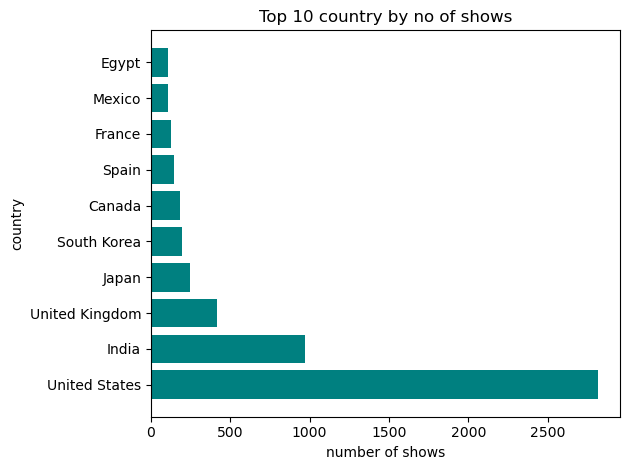

In [7]:
# top 10 country by shows

country_counts = df['country'].value_counts().head(10)

plt.barh(country_counts.index, country_counts.values, color = 'teal')
plt.title('Top 10 country by no of shows')
plt.xlabel('number of shows')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('top10_countries_by_show.png')
plt.show() 

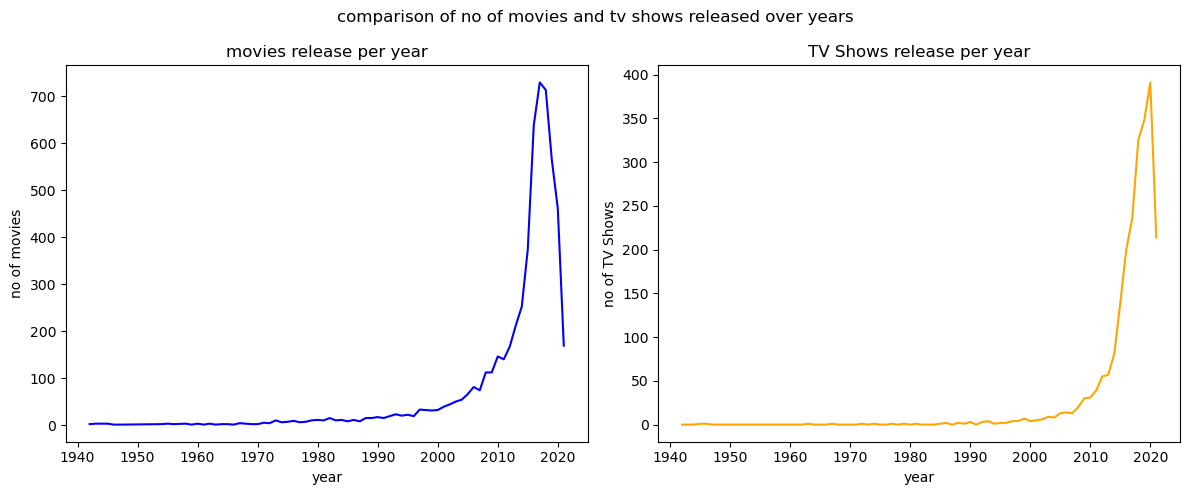

In [8]:
# movie release and TV shows per year

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))

# first subplots:Movies
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('movies release per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('no of movies')

# first subplots:TV Show
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV Shows release per year')
ax[1].set_xlabel('year')
ax[1].set_ylabel('no of TV Shows')

fig.suptitle('comparison of no of movies and tv shows released over years')

plt.tight_layout()
plt.savefig('comparion_movie_tv_show.png')
plt.show()
